In [ ]:
import json

token = {
    "username": "HEEWON CHOI_03",
    "key": "KGAT_17a4a5059c9f11827f93d5b3cae5f156"
}

with open('kaggle.json', 'w') as f:
    json.dump(token, f)

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d polomarco/chest-ct-segmentation

Dataset URL: https://www.kaggle.com/datasets/polomarco/chest-ct-segmentation
License(s): unknown
 98% 1.58G/1.61G [00:10<00:00, 85.9MB/s]
100% 1.61G/1.61G [00:10<00:00, 168MB/s] 


In [ ]:
!unzip chest-ct-segmentation.zip -d chest/

In [ ]:
!pip install ultralytics

In [ ]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.8/112.6 GB disk)


In [ ]:
# SEED FIX
import random
import numpy as np
import torch
import os

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# PyTorch 연산 결정성 확보
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Class Distribution

In [ ]:
import os
import cv2
import numpy as np
import random
import shutil
from sklearn.model_selection import train_test_split

# 경로 설정
source_img = "/content/chest/images/images"
source_mask = "/content/chest/masks/masks"

output_root = "/content/yolo_dataset"
os.makedirs(output_root, exist_ok=True)

for split in ["train", "val", "test"]:
    os.makedirs(f"{output_root}/images/{split}", exist_ok=True)
    os.makedirs(f"{output_root}/labels/{split}", exist_ok=True)

# RGB => class index 변환 함수
def rgb_to_class(mask):
    B = mask[:, :, 0]
    G = mask[:, :, 1]
    R = mask[:, :, 2]

    class_mask = np.zeros(B.shape, dtype=np.uint8)

    # 폐 (lungs) : 파란색 계열
    lungs = (B > 150) & (G < 120) & (R < 120)
    class_mask[lungs] = 1

    # 심장 (heart) : 초록색 계열
    heart = (G > 150) & (R < 150)
    class_mask[heart] = 2

    # 기관 (trachea) : 빨간색 계열
    trachea = (R > 150) & (G < 120)
    class_mask[trachea] = 3

    return class_mask

In [ ]:
# 전체 파일 목록
files = sorted([f for f in os.listdir(source_mask) if f.endswith((".jpg", ".png"))])

lungs_count = 0
heart_count = 0
trachea_count = 0

print(" RGB 기반 마스크 클래스 분포 분석 중...\n")

# 클래스 포함 여부 분석
for f in files:

    mask = cv2.imread(os.path.join(source_mask, f))
    if mask is None:
        print("⚠ 읽기 실패:", f)
        continue

    cls = rgb_to_class(mask)

    if np.any(cls == 1):
        lungs_count += 1
    if np.any(cls == 2):
        heart_count += 1
    if np.any(cls == 3):
        trachea_count += 1


# 결과 출력
print("클래스 분포 결과")
print("----------------------------")
print(f"lungs    포함 이미지 수 : {lungs_count}")
print(f"heart    포함 이미지 수 : {heart_count}")
print(f"trachea 포함 이미지 수 : {trachea_count}")
print("----------------------------")
print(f"총 마스크 이미지 : {len(files)} 장")

 RGB 기반 마스크 클래스 분포 분석 중...

 클래스 분포 결과
----------------------------
lungs    포함 이미지 수 : 12827
heart    포함 이미지 수 : 3626
trachea 포함 이미지 수 : 7808
----------------------------
총 마스크 이미지 : 16708 장


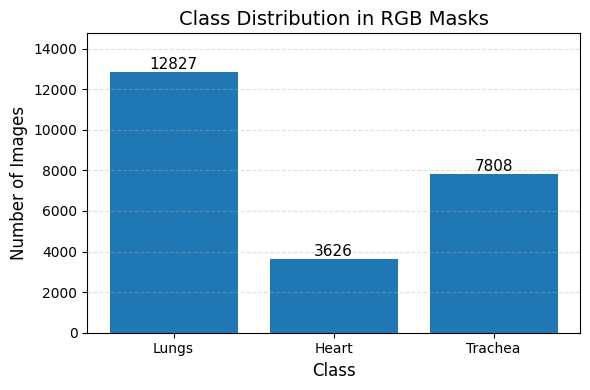

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 클래스 이름 & 개수 (앞에서 계산된 값 사용)
classes = ["Lungs", "Heart", "Trachea"]
counts = [lungs_count, heart_count, trachea_count]

# Bar Graph
plt.figure(figsize=(6, 4))

bars = plt.bar(classes, counts)

# 값 표시
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title("Class Distribution in RGB Masks", fontsize=14)
plt.ylabel("Number of Images", fontsize=12)
plt.xlabel("Class", fontsize=12)

plt.ylim(0, max(counts) * 1.15)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# (1) 파일 분류
files = sorted(os.listdir(source_mask))

lungs_list = []
heart_list = []
trachea_list = []

for f in files:
    mask = cv2.imread(os.path.join(source_mask, f))
    if mask is None:
        continue

    cls = rgb_to_class(mask)

    if np.any(cls == 1):
        lungs_list.append(f)
    if np.any(cls == 2):
        heart_list.append(f)
    if np.any(cls == 3):
        trachea_list.append(f)

print("초기 lungs :", len(lungs_list))
print("초기 heart :", len(heart_list))
print("초기 trachea :", len(trachea_list))


# (2) 비율 샘플링: lung 600, heart 100, trachea 300
TARGET_L = 600
TARGET_H = 100
TARGET_T = 300

random.shuffle(lungs_list)
random.shuffle(heart_list)
random.shuffle(trachea_list)

sel_lungs   = lungs_list[:min(TARGET_L, len(lungs_list))]
sel_heart   = heart_list[:min(TARGET_H, len(heart_list))]
sel_trachea = trachea_list[:min(TARGET_T, len(trachea_list))]

final_files = sel_lungs + sel_heart + sel_trachea
random.shuffle(final_files)

print("\n 선택된 lungs:", len(sel_lungs))
print("선택된 heart:", len(sel_heart))
print("선택된 trachea:", len(sel_trachea))
print("총 선택:", len(final_files))


# (3) YOLO Segmentation polygon 변환 함수
def mask_to_yolo_txt(class_mask, img_w, img_h, label_path):

    with open(label_path, "w") as f:

        for cls_id in [1, 2, 3]:   # lungs=1, heart=2, trachea=3

            binary = (class_mask == cls_id).astype(np.uint8)

            contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            for cnt in contours:
                if len(cnt) < 3:
                    continue

                polygon = cnt.reshape(-1, 2).astype(np.float32)
                polygon[:, 0] /= img_w
                polygon[:, 1] /= img_h

                coords = " ".join([f"{p:.6f}" for p in polygon.flatten()])
                yolo_id = cls_id - 1   # YOLO class: 0, 1, 2

                f.write(f"{yolo_id} {coords}\n")


# (4) train/val/test 나누기 (8:1:1)
train_files, temp = train_test_split(final_files, test_size=0.2, random_state=42)
val_files, test_files = train_test_split(temp, test_size=0.5, random_state=42)


# (5) 이미지/라벨 저장
def save_data(file_list, split):
    for f in file_list:

        img_name = f.replace("_mask", "")

        img_path = os.path.join(source_img, img_name)
        mask_path = os.path.join(source_mask, f)

        img = cv2.imread(img_path)
        mask = cv2.imread(mask_path)

        if img is None or mask is None:
            continue

        class_mask = rgb_to_class(mask)

        h, w = class_mask.shape

        out_img = f"{output_root}/images/{split}/{img_name}"
        base, ext = os.path.splitext(img_name)
        out_txt = f"{output_root}/labels/{split}/{base}.txt"

        shutil.copy(img_path, out_img)
        mask_to_yolo_txt(class_mask, w, h, out_txt)


save_data(train_files, "train")
save_data(val_files, "val")
save_data(test_files, "test")

print("\n YOLO Segmentation 데이터셋 생성 완료!")
print(f"경로: {output_root}")

초기 lungs : 12827
초기 heart : 3626
초기 trachea : 7808

 선택된 lungs: 600
선택된 heart: 100
선택된 trachea: 300
총 선택: 1000

 YOLO Segmentation 데이터셋 생성 완료!
경로: /content/yolo_dataset


In [ ]:
import os
from collections import Counter

label_root = "/content/yolo_dataset/labels"

splits = ["train", "val", "test"]

# YOLO class id => organ name
class_names = {
    0: "Lungs (폐)",
    1: "Heart (심장)",
    2: "Trachea (기관)",
}

for split in splits:
    folder = f"{label_root}/{split}"
    class_counter = Counter()

    for file in os.listdir(folder):
        if not file.endswith(".txt"):
            continue

        with open(os.path.join(folder, file), "r") as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) > 0:
                    cls_id = int(parts[0])
                    class_counter[cls_id] += 1

    print(f"\n {split.upper()} 클래스 분포")
    print("--------------------------------")
    for cls_id in sorted(class_counter.keys()):
        name = class_names.get(cls_id, "Unknown")
        print(f"{cls_id} ({name}) : {class_counter[cls_id]} 개")


 TRAIN 클래스 분포
--------------------------------
0 (Lungs (폐)) : 1595 개
1 (Heart (심장)) : 283 개
2 (Trachea (기관)) : 606 개

 VAL 클래스 분포
--------------------------------
0 (Lungs (폐)) : 199 개
1 (Heart (심장)) : 32 개
2 (Trachea (기관)) : 77 개

 TEST 클래스 분포
--------------------------------
0 (Lungs (폐)) : 211 개
1 (Heart (심장)) : 41 개
2 (Trachea (기관)) : 66 개


# Imbalanced Finetune

In [ ]:
# 경로 & 클래스 정의
DATA_ROOT = "/content/yolo_dataset"

TRAIN_DIR = f"{DATA_ROOT}/images/train"
VAL_DIR   = f"{DATA_ROOT}/images/val"
TEST_DIR  = f"{DATA_ROOT}/images/test"

# 클래스 순서는 전처리 코드에서 사용한 것과 반드시 동일
CLS_LIST = ["lungs", "heart", "trachea"]

In [ ]:
# YOLO data.yaml 생성
import yaml
import os

yaml_data = {
    "path": DATA_ROOT,
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": len(CLS_LIST),
    "names": CLS_LIST
}

YAML_PATH = os.path.join(DATA_ROOT, "chest_ct.yaml")

with open(YAML_PATH, "w") as f:
    yaml.dump(yaml_data, f, sort_keys=False)

print("\n 생성된 YAML 파일:", YAML_PATH)
print("내용:")
print(yaml_data)


 생성된 YAML 파일: /content/yolo_dataset/chest_ct.yaml
내용:
{'path': '/content/yolo_dataset', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'nc': 3, 'names': ['lungs', 'heart', 'trachea']}


In [ ]:
# chest_seg_finetune 학습
from ultralytics import YOLO

# Segmentation 모델 로드
model = YOLO("yolov8s-seg.pt")

# 학습
results = model.train(
    data=YAML_PATH,
    epochs=50,
    batch=16,
    imgsz=640,
    device="auto",
    patience=30,
    name="chest_seg_finetune"
)

Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:auto (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/chest_ct.yaml, degrees=0.0, deterministic=True, device=auto, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=chest_seg_finetune, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=30, perspecti

In [ ]:
# 정량 평가 : best 모델 꺼내서 test set으로 평가 (Finetune ONLY)
import os
from ultralytics import YOLO

pjt_root = "/content"
result_folder = f"{pjt_root}/runs/segment"

# Finetune 모델 경로만 사용
FINETUNE_MODEL = "/content/runs/segment/chest_seg_finetune/weights/best.pt"

# 검증 함수
def validate_model(model_path, model_name):
    if not os.path.exists(model_path):
        print(f" {model_name} 모델 파일이 존재하지 않습니다!")
        print("경로:", model_path, "\n")
        return None

    print(f"\n Validating {model_name}\n")
    model = YOLO(model_path)
    metrics = model.val(split="test")
    return metrics

# 모델 검증 (Finetune만)
finetune_metrics = validate_model(FINETUNE_MODEL, "Finetune Model")


 Validating Finetune Model

Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8s-seg summary (fused): 85 layers, 11,780,761 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1650.7±873.0 MB/s, size: 79.4 KB)
val: Scanning /content/yolo_dataset/labels/test... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 1.2Kit/s 0.1s
val: New cache created: /content/yolo_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.2it/s 5.9s
                   all        100        318      0.808      0.818      0.813       0.66      0.813      0.823      0.807      0.622
                 lungs         98        211       0.93      0.896      0.906      0.845      0.931      0.897      0.903      0.818
                 heart         33         41      0.642      0.683      0.667      0.477

 선택된 랜덤 이미지: /content/yolo_dataset/images/test/ID00400637202305055099402_47.jpg

0: 640x640 2 lungss, 1 trachea, 20.9ms
Speed: 3.6ms preprocess, 20.9ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


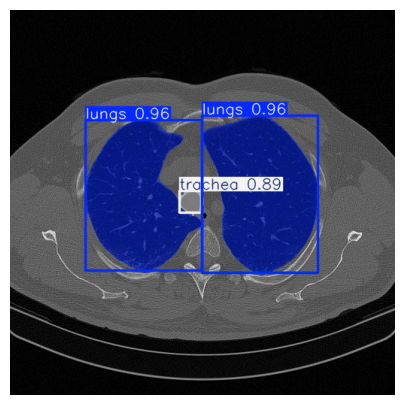

In [ ]:
# 정성 분석(추론 시각화)
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO
import glob
import random

# 1. 모델 로드 (원하는 모델 best.pt 로 변경)
model_path = "/content/runs/segment/chest_seg_finetune/weights/best.pt"
model = YOLO(model_path)

# 2. 테스트할 이미지
img_folder = "/content/yolo_dataset/images/test"

# 이미지는 전부 jpg 형식
img_paths = glob.glob(img_folder + "/*.jpg")

if len(img_paths) == 0:
    raise ValueError(f"폴더에 이미지가 없습니다: {img_folder}")

img_path = random.choice(img_paths)
print(" 선택된 랜덤 이미지:", img_path)

img_bgr = cv2.imread(img_path)
if img_bgr is None:
    raise ValueError("이미지를 찾을 수 없습니다: " + img_path)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 3. YOLO 예측
res = model(img_rgb)[0]

# 4. YOLO 내장 시각화
vis = res.plot()   # mask + bbox + label 자동 추가된 이미지

plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

선택된 랜덤 이미지: /content/chest/images/images/ID00140637202231728595149_103.jpg

0: 640x640 2 lungss, 3 hearts, 21.0ms
Speed: 3.7ms preprocess, 21.0ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)
mask_stack shape: (5, 640, 640)
cls_ids (예측된 클래스들): [0 0 1 1 1]


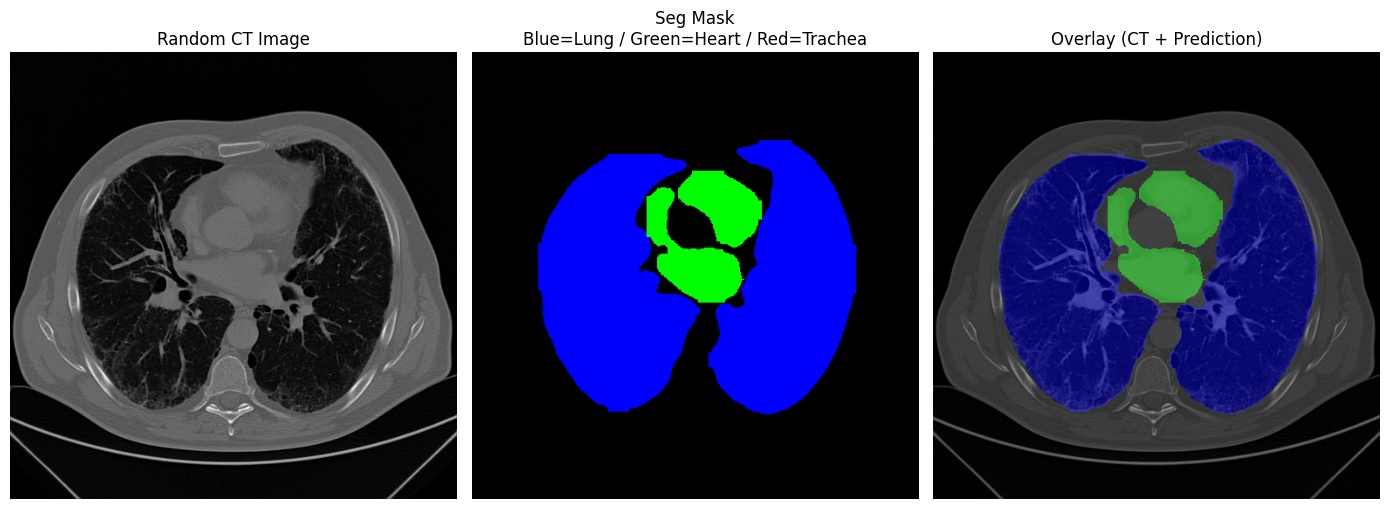

In [ ]:
# 일반화
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
import glob

# 0) 랜덤 이미지 자동 선택
img_folder = "/content/chest/images/images"   # 이미지 폴더 경로 수정 가능

# jpg
img_paths = glob.glob(img_folder + "/*.jpg")

if len(img_paths) == 0:
    raise ValueError(f"폴더에 이미지가 없습니다: {img_folder}")

img_path = random.choice(img_paths)
print("선택된 랜덤 이미지:", img_path)

# 1) 이미지 로드 (RGB 변환)
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


# 2) YOLO 모델 예측
result = model(img_rgb, conf=0.25, iou=0.7)[0]

# 3) 결과 처리
if result.masks is not None and result.masks.data is not None:
    mask_stack = result.masks.data.cpu().numpy()  # (N, Hm, Wm)
    cls_ids = result.boxes.cls.cpu().numpy().astype(int)

    print("mask_stack shape:", mask_stack.shape)
    print("cls_ids (예측된 클래스들):", cls_ids)

    H, W = img_rgb.shape[:2]
    Hm, Wm = mask_stack.shape[1:]

    # 클래스별 빈 레이어
    lungs_mask  = np.zeros((Hm, Wm), dtype=np.uint8)
    heart_mask  = np.zeros((Hm, Wm), dtype=np.uint8)
    trach_mask  = np.zeros((Hm, Wm), dtype=np.uint8)

    # 각 인스턴스 마스크 => 클래스 마스크에 OR 방식으로 합치기
    for i in range(mask_stack.shape[0]):
        m = (mask_stack[i] > 0.5).astype(np.uint8)
        cls_id = cls_ids[i]

        if cls_id == 0:      # 폐
            lungs_mask |= m
        elif cls_id == 1:    # 심장
            heart_mask |= m
        elif cls_id == 2:    # 기관
            trach_mask |= m

    # 4) 컬러 마스크 생성
    mask_rgb_small = np.zeros((Hm, Wm, 3), dtype=np.uint8)

    # 폐 = 파랑
    mask_rgb_small[lungs_mask == 1] = (0, 0, 255)

    # 심장 = 초록
    mask_rgb_small[heart_mask == 1] = (0, 255, 0)

    # 기관 = 빨강
    mask_rgb_small[trach_mask == 1] = (255, 0, 0)

    # 원본 크기로 키우기
    mask_rgb = cv2.resize(mask_rgb_small, (W, H), interpolation=cv2.INTER_NEAREST)

    # 5) 오버레이 생성 (CT + 색마스크)
    overlay = (img_rgb * 0.6 + mask_rgb * 0.4).astype(np.uint8)

    # 6) 시각화
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    plt.title("Random CT Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_rgb)
    plt.title("Seg Mask\nBlue=Lung / Green=Heart / Red=Trachea")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Overlay (CT + Prediction)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

else:
    print("예측된 mask가 없습니다. 해당 모델이 이 이미지에서 객체를 못 찾았습니다.")

# Balanced + heart refinement

In [ ]:
# 1. 시드 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [ ]:
# YOLO로 변환된 전체 데이터 풀을 한 번 다시 모아서(train 폴더)
DATA_ROOT = "/content/yolo_dataset"
IMG_DIR = f"{DATA_ROOT}/images/train"
LBL_DIR = f"{DATA_ROOT}/labels/train"

# 그 풀을 기준으로 train / val을 새로 나누는 단계
output_root_bal = "/content/yolo_dataset_balanced"

for split in ["train", "val"]:
    os.makedirs(f"{output_root_bal}/images/{split}", exist_ok=True)
    os.makedirs(f"{output_root_bal}/labels/{split}", exist_ok=True)

In [ ]:
# heart 품질 판별 함수
def is_good_heart_label(txt_path, min_points=20, min_bbox_area=0.001):
    if not os.path.exists(txt_path):
        return False

    with open(txt_path) as f:
        lines = f.readlines()

    heart_polys = []
    for line in lines:
        parts = line.strip().split()
        cls = int(parts[0])
        if cls == 1:  # heart
            coords = np.array(parts[1:], dtype=float).reshape(-1, 2)
            heart_polys.append(coords)

    if len(heart_polys) == 0:
        return False

    poly = max(heart_polys, key=lambda p: p.shape[0])

    if poly.shape[0] < min_points:
        return False

    x_min, y_min = poly.min(axis=0)
    x_max, y_max = poly.max(axis=0)
    area = (x_max - x_min) * (y_max - y_min)

    if area < min_bbox_area:
        return False

    return True

In [ ]:
# 클래스별 파일 수집 (YOLO txt 기준)
lungs_list = []
heart_list = []
trachea_list = []

for txt in sorted(os.listdir(LBL_DIR)):
    if not txt.endswith(".txt"):
        continue

    txt_path = os.path.join(LBL_DIR, txt)
    with open(txt_path) as f:
        classes = {int(line.split()[0]) for line in f.readlines()}

    img = txt.replace(".txt", ".png")

    if 0 in classes:
        lungs_list.append(img)
    if 1 in classes:
        heart_list.append(img)
    if 2 in classes:
        trachea_list.append(img)

print("초기 lungs:", len(lungs_list))
print("초기 heart:", len(heart_list))
print("초기 trachea:", len(trachea_list))

초기 lungs: 741
초기 heart: 244
초기 trachea: 497


In [ ]:
# 4:3:3 균형 + heart 정제
TARGET_L = 400
TARGET_H = 300
TARGET_T = 300

random.shuffle(lungs_list)
random.shuffle(trachea_list)

# heart만 정제 필터 적용
heart_refined = []
for img in heart_list:
    txt_path = os.path.join(LBL_DIR, img.replace(".png", ".txt"))
    if is_good_heart_label(txt_path):
        heart_refined.append(img)

random.shuffle(heart_refined)

sel_lungs = lungs_list[:min(TARGET_L, len(lungs_list))]
sel_heart = heart_refined[:min(TARGET_H, len(heart_refined))]
sel_trachea = trachea_list[:min(TARGET_T, len(trachea_list))]

final_files = sel_lungs + sel_heart + sel_trachea
random.shuffle(final_files)

print("선택 lungs:", len(sel_lungs))
print("선택 heart (refined):", len(sel_heart))
print("선택 trachea:", len(sel_trachea))
print("총 선택:", len(final_files))

선택 lungs: 400
선택 heart (refined): 240
선택 trachea: 300
총 선택: 940


In [ ]:
# train / val 분리
from sklearn.model_selection import train_test_split

train_files, val_files = train_test_split(
    final_files,
    test_size=0.2,
    random_state=SEED
)

In [ ]:
import os, glob, shutil

SRC_ROOT = "/content/yolo_dataset"
DST_ROOT = "/content/yolo_dataset_heart_refined"

def ensure_dirs(root):
    for p in [
        f"{root}/images/train", f"{root}/images/val",
        f"{root}/labels/train", f"{root}/labels/val",
    ]:
        os.makedirs(p, exist_ok=True)

def index_images(img_dir):
    exts = ("*.jpg", "*.jpeg", "*.png")
    paths = []
    for e in exts:
        paths += glob.glob(os.path.join(img_dir, e))
    return {os.path.splitext(os.path.basename(p))[0]: p for p in paths}

def copy_split_with_stem(files, split):
    # split별로 원본 폴더도 train/val에 맞춰서 사용
    img_map = index_images(f"{SRC_ROOT}/images/{split}")
    lbl_dir = f"{SRC_ROOT}/labels/{split}"

    img_dst = f"{DST_ROOT}/images/{split}"
    lbl_dst = f"{DST_ROOT}/labels/{split}"
    os.makedirs(img_dst, exist_ok=True)
    os.makedirs(lbl_dst, exist_ok=True)

    copied = 0
    miss_img = 0
    miss_lbl = 0

    for name in files:
        stem = os.path.splitext(name)[0]
        lbl_src = os.path.join(lbl_dir, stem + ".txt")

        if stem not in img_map:
            miss_img += 1
            continue
        if not os.path.exists(lbl_src):
            miss_lbl += 1
            continue

        src_img = img_map[stem]
        shutil.copy(src_img, os.path.join(img_dst, os.path.basename(src_img)))  # 원본 확장자 유지
        shutil.copy(lbl_src, os.path.join(lbl_dst, stem + ".txt"))
        copied += 1

    print(f"{split} copied: {copied} (missing_img={miss_img}, missing_lbl={miss_lbl})")

# 실행
ensure_dirs(DST_ROOT)
copy_split_with_stem(train_files, "train")
copy_split_with_stem(val_files, "val")
print("heart_refined 데이터셋 복사 완료")

train copied: 752 (missing_img=0, missing_lbl=0)
val copied: 1 (missing_img=187, missing_lbl=0)
heart_refined 데이터셋 복사 완료


In [ ]:
# YOLO data.yaml 생성 (heart refined dataset)
import yaml
import os

# 4:3:3 + heart 품질 정제까지 끝난 최종 데이터셋
DATA_ROOT = "/content/yolo_dataset_heart_refined"

# 클래스 순서 (기존과 반드시 동일)
CLS_LIST = ["lungs", "heart", "trachea"]

yaml_data = {
    "path": DATA_ROOT,
    "train": "images/train",
    "val": "images/val",
    "test": "/content/yolo_dataset/images/test",   # ✅ test는 기존과 동일 기준
    "nc": len(CLS_LIST),
    "names": CLS_LIST
}

YAML_PATH = os.path.join(DATA_ROOT, "chest_ct_heart_refined.yaml")

with open(YAML_PATH, "w") as f:
    yaml.dump(yaml_data, f, sort_keys=False)

print("\n 생성된 YAML 파일:", YAML_PATH)
print(" 내용:")
print(yaml_data)


 생성된 YAML 파일: /content/yolo_dataset_heart_refined/chest_ct_heart_refined.yaml
 내용:
{'path': '/content/yolo_dataset_heart_refined', 'train': 'images/train', 'val': 'images/val', 'test': '/content/yolo_dataset/images/test', 'nc': 3, 'names': ['lungs', 'heart', 'trachea']}


In [ ]:
model = YOLO("yolov8s-seg.pt")

model.train(
    data=YAML_PATH,
    epochs=50,
    batch=16,
    imgsz=640,
    device="auto",
    patience=30,
    name="chest_seg_finetune_heart_refined"
)

Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:auto (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset_heart_refined/chest_ct_heart_refined.yaml, degrees=0.0, deterministic=True, device=auto, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=chest_seg_finetune_heart_refined, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto,

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a91f06911c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.04

In [ ]:
# 정량 평가(Imbalance vs. Balanced_heart refinement)
import os
from ultralytics import YOLO

pjt_root = "/content"
result_folder = f"{pjt_root}/runs/segment"

# 모델 경로
FINETUNE_MODEL_IMB = "/content/runs/segment/chest_seg_finetune/weights/best.pt"
FINETUNE_MODEL_HEART = "/content/runs/segment/chest_seg_finetune_heart_refined/weights/best.pt"

# 검증 함수
def validate_model(model_path, model_name):
    if not os.path.exists(model_path):
        print(f" {model_name} 모델 파일이 존재하지 않습니다!")
        print("경로:", model_path, "\n")
        return None

    print(f"\n Validating {model_name}\n")
    model = YOLO(model_path)
    metrics = model.val(
    data=YAML_PATH,
    split="test"
)
    return metrics

# 모델 검증
finetune_imb_metrics = validate_model(FINETUNE_MODEL_IMB, "Finetune Model (Imbalanced)")
finetune_heart_metrics = validate_model(FINETUNE_MODEL_HEART, "Finetune Model (Balanced_Heart Refined)")


 Validating Finetune Model (Imbalanced)

Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8s-seg summary (fused): 85 layers, 11,780,761 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1266.0±432.2 MB/s, size: 103.7 KB)
val: Scanning /content/yolo_dataset/labels/test.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 158.3Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.0it/s 6.9s
                   all        100        318      0.808      0.818      0.813       0.66      0.813      0.823      0.807      0.622
                 lungs         98        211       0.93      0.896      0.906      0.845      0.931      0.897      0.903      0.818
                 heart         33         41      0.642      0.683      0.667      0.477      0.642      0.683      0.646      0.4

#Heart Oversampling & Data Augmentation Model

In [ ]:
# 시드 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [ ]:
import os, glob, shutil

SRC_ROOT = "/content/yolo_dataset"
DST_ROOT = "/content/yolo_dataset_balanced"

def ensure_dirs(root):
    for p in [
        f"{root}/images/train", f"{root}/images/val",
        f"{root}/labels/train", f"{root}/labels/val",
    ]:
        os.makedirs(p, exist_ok=True)

def index_images(split):
    img_dir = f"{SRC_ROOT}/images/{split}"
    imgs = []
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        imgs += glob.glob(os.path.join(img_dir, ext))
    return {os.path.splitext(os.path.basename(p))[0]: p for p in imgs}

def copy_split(files, split):
    img_map = index_images(split)
    lbl_dir = f"{SRC_ROOT}/labels/{split}"

    img_dst = f"{DST_ROOT}/images/{split}"
    lbl_dst = f"{DST_ROOT}/labels/{split}"

    copied = 0
    miss_img = 0
    miss_lbl = 0

    for name in files:
        stem = os.path.splitext(name)[0]
        lbl_src = os.path.join(lbl_dir, stem + ".txt")

        if stem not in img_map:
            miss_img += 1
            continue
        if not os.path.exists(lbl_src):
            miss_lbl += 1
            continue

        shutil.copy(img_map[stem], os.path.join(img_dst, os.path.basename(img_map[stem])))
        shutil.copy(lbl_src, os.path.join(lbl_dst, stem + ".txt"))
        copied += 1

    print(f"{split} copied: {copied} (missing_img={miss_img}, missing_lbl={miss_lbl})")

# 실행
ensure_dirs(DST_ROOT)
copy_split(train_files, "train")
copy_split(val_files, "val")

train copied: 752 (missing_img=0, missing_lbl=0)
val copied: 1 (missing_img=187, missing_lbl=0)


In [ ]:
import glob
import os

DATA_ROOT = "/content/yolo_dataset_balanced"
IMG_TRAIN_DIR = os.path.join(DATA_ROOT, "images/train")
TXT_PATH = os.path.join(DATA_ROOT, "train_heartboost.txt")

# train 이미지 수집 (.jpg / .png / .jpeg)
train_imgs = []
for ext in ("*.jpg", "*.jpeg", "*.png"):
    train_imgs += glob.glob(os.path.join(IMG_TRAIN_DIR, ext))

if not train_imgs:
    raise RuntimeError("images/train 안에 이미지가 없습니다")

# 절대경로로 저장 (YOLO txt 방식 요구)
with open(TXT_PATH, "w") as f:
    for p in sorted(train_imgs):
        f.write(os.path.abspath(p) + "\n")

print("train_heartboost.txt 생성 완료")
print("경로:", TXT_PATH)
print("이미지 수:", len(train_imgs))

train_heartboost.txt 생성 완료
경로: /content/yolo_dataset_balanced/train_heartboost.txt
이미지 수: 558


In [ ]:
# YOLO data.yaml 생성 (heart oversampling dataset)
import yaml
import os

# 데이터 루트
DATA_ROOT = "/content/yolo_dataset_balanced"
YAML_PATH = os.path.join(DATA_ROOT, "chest_ct_balanced_heartboost.yaml")

# 클래스 순서 (기존 모델과 반드시 동일)
CLS_LIST = ["lungs", "heart", "trachea"]


# YAML 내용
yaml_data = {
    "path": DATA_ROOT,
    "train": os.path.join(DATA_ROOT, "train_heartboost.txt"),  # heart oversampling
    "val": "images/val",                                       # 폴더 기반 val
    "test": "/content/yolo_dataset/images/test",               # 고정 test
    "nc": len(CLS_LIST),
    "names": CLS_LIST
}


# YAML 저장
with open(YAML_PATH, "w") as f:
    yaml.safe_dump(yaml_data, f, sort_keys=False)

print("Heart Oversampling YAML 생성 완료")
print("경로:", YAML_PATH)
print("내용:")
print(yaml_data)

Heart Oversampling YAML 생성 완료
경로: /content/yolo_dataset_balanced/chest_ct_balanced_heartboost.yaml
내용:
{'path': '/content/yolo_dataset_balanced', 'train': '/content/yolo_dataset_balanced/train_heartboost.txt', 'val': 'images/val', 'test': '/content/yolo_dataset/images/test', 'nc': 3, 'names': ['lungs', 'heart', 'trachea']}


In [ ]:
from ultralytics import YOLO

# 0) YAML 경로
YAML_PATH = "/content/yolo_dataset_balanced/chest_ct_balanced_heartboost.yaml"

# 1) 공통 Augmentation 설정 (통제 변수)
COMMON_AUG = dict(
    mosaic=0.0,       # 경계 깨짐 방지
    mixup=0.0,
    copy_paste=0.25,  # 형태 다양성만 약간
    translate=0.05,
    scale=0.3
)

# 2) 공통 학습 설정 (통제 변수)
COMMON_TRAIN = dict(
    epochs=50,
    batch=16,
    imgsz=640,
    device="auto",
    patience=30
)

# 3) 모델 로드
model = YOLO("yolov8s-seg.pt")

# 4) 학습 실행 (HeartBoost Balanced)
results = model.train(
    data=YAML_PATH,
    name="chest_seg_finetune_balanced_heartboost",
    # 통제 변수들
    **COMMON_TRAIN,
    **COMMON_AUG
)

Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:auto (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.25, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset_balanced/chest_ct_balanced_heartboost.yaml, degrees=0.0, deterministic=True, device=auto, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=0.0, multi_scale=False, name=chest_seg_finetune_balanced_heartboost2, nbs=64, nms=False, opset=None, optimize=False, optimi

In [ ]:
import os
from ultralytics import YOLO

# 모델 경로
FINETUNE_MODEL_IMB = "/content/runs/segment/chest_seg_finetune/weights/best.pt"
FINETUNE_MODEL_HEART = "/content/runs/segment/chest_seg_finetune_heart_refined/weights/best.pt"
HEARTBOOST_MODEL = "/content/runs/segment/chest_seg_finetune_balanced_heartboost/weights/best.pt"

# 모델별 YAML 경로
# (각 모델 학습에 사용한 YAML 그대로)
YAML_IMB = "/content/yolo_dataset/chest_ct.yaml"
YAML_HEART = "/content/yolo_dataset_heart_refined/chest_ct_heart_refined.yaml"
YAML_HEARTBOOST = "/content/yolo_dataset_balanced/chest_ct_balanced_heartboost.yaml"


# 검증 함수
def validate_model(model_path, model_name, yaml_path):
    if not os.path.exists(model_path):
        print(f"{model_name} 모델 파일이 없습니다.")
        print("경로:", model_path)
        return None

    print(f"\nValidating {model_name}")
    model = YOLO(model_path)

    metrics = model.val(
        data=yaml_path,
        split="test",
        save=False
    )
    return metrics


# 검증 실행
imb_metrics = validate_model(
    FINETUNE_MODEL_IMB,
    "Finetune Model (Imbalanced)",
    YAML_IMB
)

heart_refined_metrics = validate_model(
    FINETUNE_MODEL_HEART,
    "Finetune Model (Balanced_Heart Refined)",
    YAML_HEART
)

heartboost_metrics = validate_model(
    HEARTBOOST_MODEL,
    "Finetune Model (Heart Oversampling)",
    YAML_HEARTBOOST
)


Validating Finetune Model (Imbalanced)
Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8s-seg summary (fused): 85 layers, 11,780,761 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2003.7±753.8 MB/s, size: 103.7 KB)
val: Scanning /content/yolo_dataset/labels/test.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 178.1Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.2it/s 6.0s
                   all        100        318      0.808      0.818      0.813       0.66      0.813      0.823      0.807      0.622
                 lungs         98        211       0.93      0.896      0.906      0.845      0.931      0.897      0.903      0.818
                 heart         33         41      0.642      0.683      0.667      0.477      0.642      0.683      0.646      0.436

#test 이미지 직접 추론
정성 분석 (test 결과 눈으로 확인) - 3개 모델 비교

비교 이미지: ID00019637202178323708467_14.jpg

0: 640x640 2 lungss, 20.9ms
Speed: 3.8ms preprocess, 20.9ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 lungss, 20.9ms
Speed: 2.6ms preprocess, 20.9ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 lungss, 1 heart, 20.9ms
Speed: 3.0ms preprocess, 20.9ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)


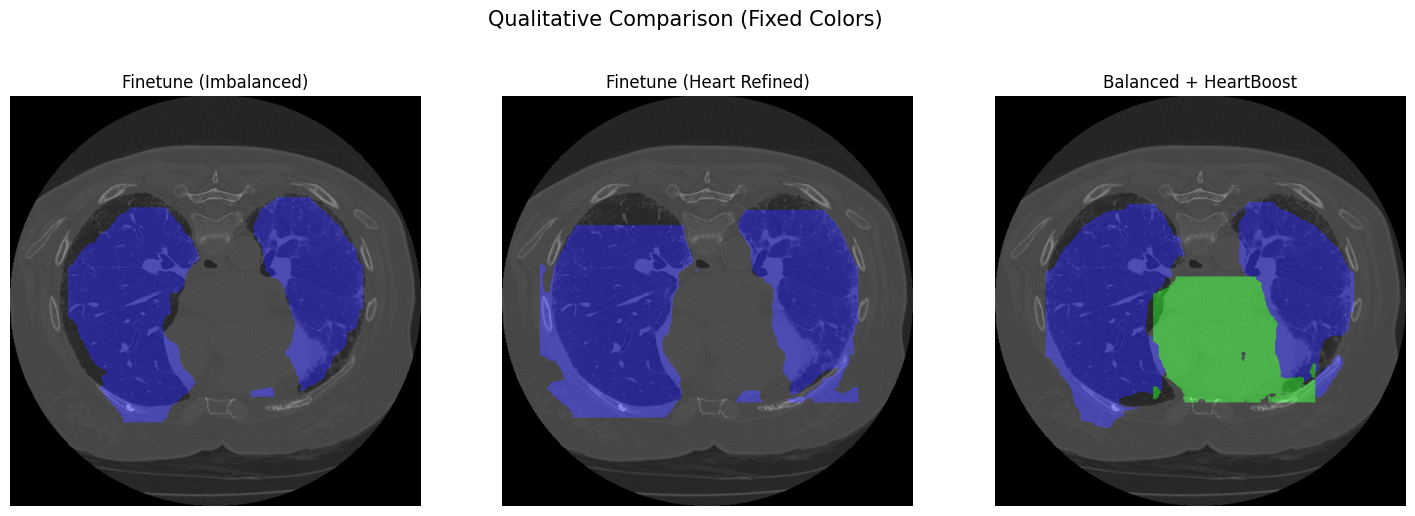

In [ ]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO


# 1) 모델 로드 (3개)
MODEL_IMB = YOLO("/content/runs/segment/chest_seg_finetune/weights/best.pt")
MODEL_HRE = YOLO("/content/runs/segment/chest_seg_finetune_heart_refined/weights/best.pt")
MODEL_HB  = YOLO("/content/runs/segment/chest_seg_finetune_balanced_heartboost/weights/best.pt")


# 2) test 이미지 선택
TEST_IMG_DIR = "/content/yolo_dataset/images/test"
img_exts = (".jpg", ".jpeg", ".png")

imgs = [os.path.join(TEST_IMG_DIR, f)
        for f in os.listdir(TEST_IMG_DIR)
        if f.lower().endswith(img_exts)]

img_path = random.choice(imgs)
print("비교 이미지:", os.path.basename(img_path))


# 3) 색상 고정 오버레이 함수
def overlay_segmentation(image_bgr, result):
    H, W = image_bgr.shape[:2]
    overlay = image_bgr.copy()

    if result.masks is None:
        return overlay

    masks = result.masks.data.cpu().numpy()   # (N, Hm, Wm)
    cls_ids = result.boxes.cls.cpu().numpy().astype(int)
    Hm, Wm = masks.shape[1:]

    lungs = np.zeros((Hm, Wm), np.uint8)
    heart = np.zeros((Hm, Wm), np.uint8)
    trach = np.zeros((Hm, Wm), np.uint8)

    for i in range(len(masks)):
        m = (masks[i] > 0.5).astype(np.uint8)
        if cls_ids[i] == 0:
            lungs |= m
        elif cls_ids[i] == 1:
            heart |= m
        elif cls_ids[i] == 2:
            trach |= m

    # RGB 기준 색상 고정
    mask_rgb = np.zeros((Hm, Wm, 3), dtype=np.uint8)
    mask_rgb[lungs == 1] = (0, 0, 255)    # Lung = Blue
    mask_rgb[heart == 1] = (0, 255, 0)    # Heart = Green
    mask_rgb[trach == 1] = (255, 0, 0)    # Trachea = Red

    mask_rgb = cv2.resize(mask_rgb, (W, H), interpolation=cv2.INTER_NEAREST)
    mask_bgr = cv2.cvtColor(mask_rgb, cv2.COLOR_RGB2BGR)

    overlay = cv2.addWeighted(image_bgr, 0.6, mask_bgr, 0.4, 0)
    return overlay


# 4) 추론
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

res_imb = MODEL_IMB(img_rgb, conf=0.25)[0]
res_bal = MODEL_HRE(img_rgb, conf=0.25)[0]
res_hb  = MODEL_HB(img_rgb, conf=0.25)[0]

out_imb = overlay_segmentation(img_bgr, res_imb)
out_bal = overlay_segmentation(img_bgr, res_bal)
out_hb  = overlay_segmentation(img_bgr, res_hb)


# 5) 나란히 시각화 (3개)
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(out_imb[..., ::-1])
plt.title("Finetune (Imbalanced)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(out_bal[..., ::-1])
plt.title("Finetune (Heart Refined)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(out_hb[..., ::-1])
plt.title("Balanced + HeartBoost")
plt.axis("off")

plt.suptitle("Qualitative Comparison (Fixed Colors)", fontsize=15)

plt.show()

#images 폴더 추론
일반화 / 데모 (처음 보는 이미지)

데모 이미지 수: 17011

0: 640x640 2 lungss, 1 trachea, 20.9ms
Speed: 2.9ms preprocess, 20.9ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


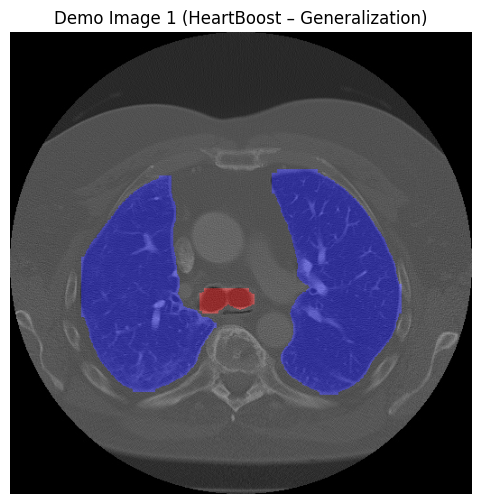


0: 640x640 2 lungss, 1 heart, 21.0ms
Speed: 5.7ms preprocess, 21.0ms inference, 2.7ms postprocess per image at shape (1, 3, 640, 640)


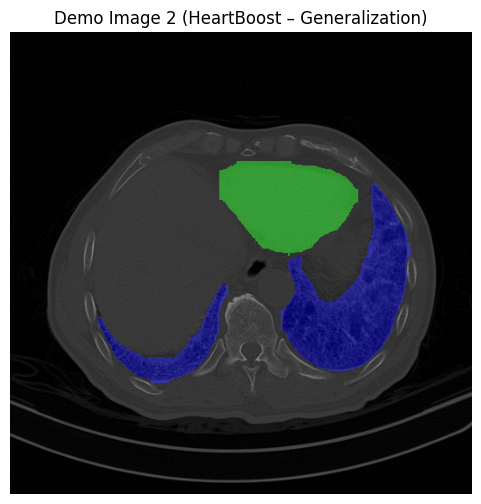


0: 640x640 2 lungss, 2 tracheas, 24.1ms
Speed: 5.0ms preprocess, 24.1ms inference, 4.6ms postprocess per image at shape (1, 3, 640, 640)


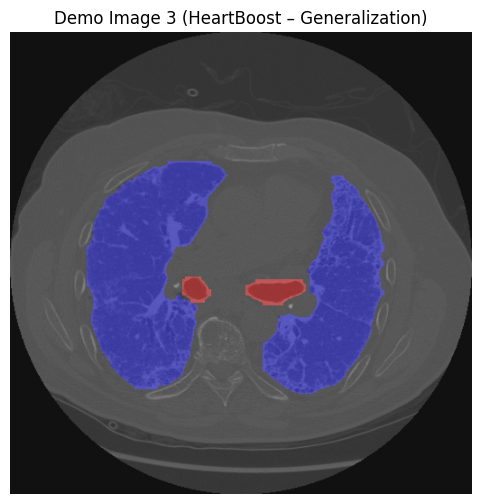

In [ ]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO


# 1) 모델 로드 (HeartBoost)
model = YOLO("/content/runs/segment/chest_seg_finetune_balanced_heartboost/weights/best.pt")


# 2) 데모 이미지 폴더 (학습/테스트 미포함)
DEMO_IMG_DIR = "/content/chest/images/images"

img_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")
demo_imgs = [
    os.path.join(DEMO_IMG_DIR, f)
    for f in os.listdir(DEMO_IMG_DIR)
    if f.lower().endswith(img_exts)
]

print(f"데모 이미지 수: {len(demo_imgs)}")

# 일부 샘플만 선택
N_SHOW = 3
sample_imgs = random.sample(demo_imgs, min(N_SHOW, len(demo_imgs)))


# 3) 색상 고정 오버레이 함수
def overlay_segmentation(image_bgr, result):
    H, W = image_bgr.shape[:2]
    overlay = image_bgr.copy()

    if result.masks is None or result.masks.data is None:
        return overlay

    masks = result.masks.data.cpu().numpy()   # (N, Hm, Wm)
    cls_ids = result.boxes.cls.cpu().numpy().astype(int)
    Hm, Wm = masks.shape[1:]

    lungs = np.zeros((Hm, Wm), np.uint8)
    heart = np.zeros((Hm, Wm), np.uint8)
    trach = np.zeros((Hm, Wm), np.uint8)

    for i in range(len(masks)):
        m = (masks[i] > 0.5).astype(np.uint8)
        if cls_ids[i] == 0:
            lungs |= m
        elif cls_ids[i] == 1:
            heart |= m
        elif cls_ids[i] == 2:
            trach |= m

    # 색상 고정 (RGB)
    mask_rgb = np.zeros((Hm, Wm, 3), dtype=np.uint8)
    mask_rgb[lungs == 1] = (0, 0, 255)    # Lung = Blue
    mask_rgb[heart == 1] = (0, 255, 0)    # Heart = Green
    mask_rgb[trach == 1] = (255, 0, 0)    # Trachea = Red

    mask_rgb = cv2.resize(mask_rgb, (W, H), interpolation=cv2.INTER_NEAREST)
    mask_bgr = cv2.cvtColor(mask_rgb, cv2.COLOR_RGB2BGR)

    overlay = cv2.addWeighted(image_bgr, 0.6, mask_bgr, 0.4, 0)
    return overlay

# 4) 추론 + 시각화
for i, img_path in enumerate(sample_imgs):
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    result = model(img_rgb, conf=0.25)[0]
    out = overlay_segmentation(img_bgr, result)

    plt.figure(figsize=(6, 6))
    plt.imshow(out[..., ::-1])
    plt.title(f"Demo Image {i+1} (HeartBoost – Generalization)")
    plt.axis("off")
    plt.show()

#IoU 계산

In [ ]:
import os
import cv2
import glob
import numpy as np
from ultralytics import YOLO


# 0) 공통 함수들
def polygon_to_mask(img_shape, poly):
    mask = np.zeros(img_shape[:2], dtype=np.uint8)
    poly_np = np.array(poly, dtype=np.int32).reshape((-1, 2))
    cv2.fillPoly(mask, [poly_np], 1)
    return mask

def compute_iou(pred_mask, true_mask):
    intersection = np.logical_and(pred_mask, true_mask).sum()
    union = np.logical_or(pred_mask, true_mask).sum()
    if union == 0:
        return np.nan
    return intersection / union

def load_gt_mask(label_path, img_shape):
    """
    3 classes: 0=lung, 1=heart, 2=trachea
    YOLO Seg label format
    """
    mask = np.zeros((3, img_shape[0], img_shape[1]), dtype=np.uint8)

    if not os.path.exists(label_path):
        return mask

    with open(label_path, "r") as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) < 3:
                continue

            cls = int(parts[0])
            coords = list(map(float, parts[1:]))

            if len(coords) % 2 != 0:
                continue

            coords = np.array(coords).reshape(-1, 2)

            coords[:, 0] *= img_shape[1]
            coords[:, 1] *= img_shape[0]

            if cls in [0, 1, 2]:
                mask_cls = polygon_to_mask(img_shape, coords)
                mask[cls] |= mask_cls

    return mask


# 1) 고정 Test set
test_img_dir   = "/content/yolo_dataset/images/test/"
test_label_dir = "/content/yolo_dataset/labels/test/"

img_exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff", "*.webp")
img_paths = []
for ext in img_exts:
    img_paths += glob.glob(os.path.join(test_img_dir, ext))
img_paths = sorted(img_paths)

print("테스트 이미지 수:", len(img_paths))
if len(img_paths) == 0:
    raise FileNotFoundError(f"test 이미지가 없습니다: {test_img_dir}")


# 2) 평가할 3개 모델 경로
model_paths = {
    "Finetune(Imbalanced)": "/content/runs/segment/chest_seg_finetune/weights/best.pt",
    "Finetune(Heart Refined)": "/content/runs/segment/chest_seg_finetune_heart_refined/weights/best.pt",
    "Balanced(HeartBoost)": "/content/runs/segment/chest_seg_finetune_balanced_heartboost/weights/best.pt",
}

# 존재 체크
for name, path in model_paths.items():
    if not os.path.exists(path):
        print(f"모델 파일 없음: {name} -> {path}")


# 3) IoU 계산
results = {}

for model_name, model_path in model_paths.items():
    if not os.path.exists(model_path):
        results[model_name] = {"Lung": np.nan, "Heart": np.nan, "Trachea": np.nan, "Mean": np.nan}
        continue

    print(f"\n==============================")
    print(f"{model_name} 모델 평가 중...")
    print(f"  모델 경로: {model_path}")
    print(f"==============================")

    model = YOLO(model_path)

    class_iou_list = {0: [], 1: [], 2: []}

    for img_path in img_paths:
        img = cv2.imread(img_path)
        if img is None:
            continue
        h, w = img.shape[:2]

        base = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(test_label_dir, base + ".txt")
        gt_mask = load_gt_mask(label_path, (h, w))

        pred = model(img, conf=0.25, iou=0.7)[0]

        pred_mask = np.zeros((3, h, w), dtype=np.uint8)
        if pred.masks is not None and pred.boxes is not None:
            masks = pred.masks.data.cpu().numpy()
            cls_ids = pred.boxes.cls.cpu().numpy().astype(int)

            for i in range(len(masks)):
                m = (masks[i] > 0.5).astype(np.uint8)
                m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)
                cid = cls_ids[i]
                if cid in [0, 1, 2]:
                    pred_mask[cid] |= m

        for cls in [0, 1, 2]:
            iou = compute_iou(pred_mask[cls], gt_mask[cls])
            if not np.isnan(iou):
                class_iou_list[cls].append(iou)

    lung_iou    = np.mean(class_iou_list[0]) if class_iou_list[0] else np.nan
    heart_iou   = np.mean(class_iou_list[1]) if class_iou_list[1] else np.nan
    trachea_iou = np.mean(class_iou_list[2]) if class_iou_list[2] else np.nan
    mean_iou    = np.nanmean([lung_iou, heart_iou, trachea_iou])

    results[model_name] = {
        "Lung": lung_iou,
        "Heart": heart_iou,
        "Trachea": trachea_iou,
        "Mean": mean_iou
    }

    print("\n클래스별 IoU 결과")
    print(f"Lung IoU     : {lung_iou:.4f}")
    print(f"Heart IoU    : {heart_iou:.4f}")
    print(f"Trachea IoU  : {trachea_iou:.4f}")
    print(f"Mean IoU   : {mean_iou:.4f}")


# 4) 결과 비교 출력 (3 Models)
print("\n==============================")
print("최종 IoU 비교 (3 Models)")
print("==============================")

print_order = ["Finetune(Imbalanced)", "Finetune(Heart Refined)", "Balanced(HeartBoost)"]

for model_name in print_order:
    vals = results.get(model_name, None)
    if vals is None:
        continue
    print(f"\n[{model_name}]")
    print(f"  Lung IoU     : {vals['Lung']:.4f}")
    print(f"  Heart IoU    : {vals['Heart']:.4f}")
    print(f"  Trachea IoU  : {vals['Trachea']:.4f}")
    print(f"  Mean IoU     : {vals['Mean']:.4f}")

테스트 이미지 수: 100

Finetune(Imbalanced) 모델 평가 중...
  모델 경로: /content/runs/segment/chest_seg_finetune/weights/best.pt

0: 640x640 2 lungss, 1 trachea, 20.9ms
Speed: 3.5ms preprocess, 20.9ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 lungss, 3 hearts, 21.0ms
Speed: 3.8ms preprocess, 21.0ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 trachea, 20.9ms
Speed: 3.4ms preprocess, 20.9ms inference, 3.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 lungss, 1 trachea, 20.9ms
Speed: 4.0ms preprocess, 20.9ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 lungss, 1 trachea, 20.9ms
Speed: 3.8ms preprocess, 20.9ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 lungss, 1 trachea, 19.5ms
Speed: 3.1ms preprocess, 19.5ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 lungss, 2 tracheas, 16.0ms
Speed: 2.7ms preprocess, 16.0ms in

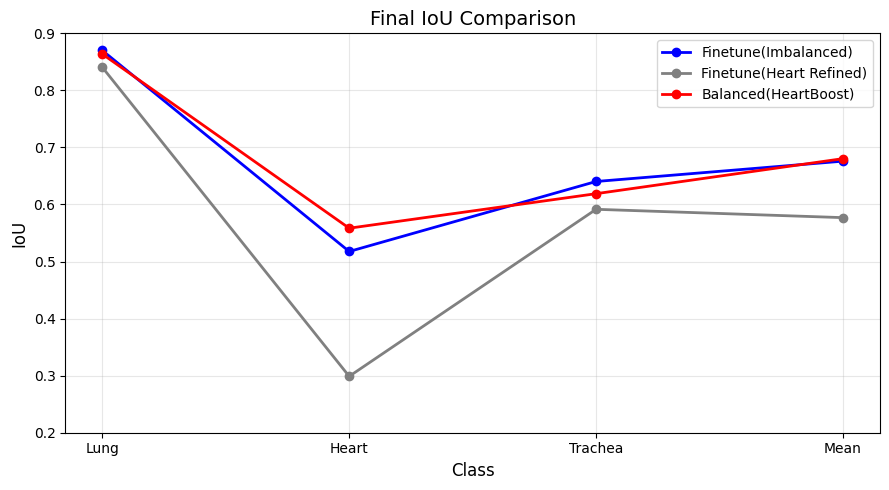

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# 그래프용 데이터
models = [
    "Finetune(Imbalanced)",
    "Finetune(Heart Refined)",
    "Balanced(HeartBoost)"
]

classes = ["Lung", "Heart", "Trachea", "Mean"]

iou_values = np.array([
    [results[m]["Lung"], results[m]["Heart"], results[m]["Trachea"], results[m]["Mean"]]
    for m in models
])

colors = {
    "Finetune(Imbalanced)": "blue",
    "Finetune(Heart Refined)": "gray",
    "Balanced(HeartBoost)": "red"
}


# 라인 그래프
plt.figure(figsize=(9, 5))

for i, model in enumerate(models):
    plt.plot(
        classes,
        iou_values[i],
        marker="o",
        linewidth=2,
        color=colors[model],
        label=model
    )

plt.ylim(0.2, 0.9)
plt.yticks(np.arange(0.2, 0.91, 0.1))

plt.xlabel("Class", fontsize=12)
plt.ylabel("IoU", fontsize=12)
plt.title("Final IoU Comparison", fontsize=14)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Heart refinement만 적용한 경우,
라벨 품질은 향상되었으나
클래스 불균형 문제가 해결되지 않아
오히려 segmentation 성능이 저하되었다.

반면 Heart oversampling + data aumentation 방식은
heart 클래스의 학습 빈도를 증가시키면서도
다른 클래스 성능을 유지하여
가장 높은 Mean IoU를 달성하였다.

성능 향상이 **모델 구조 변경**이 아닌 **데이터 분포 개선**에 기인함을 의미한다.

#비디오 영상 처리 (응용)



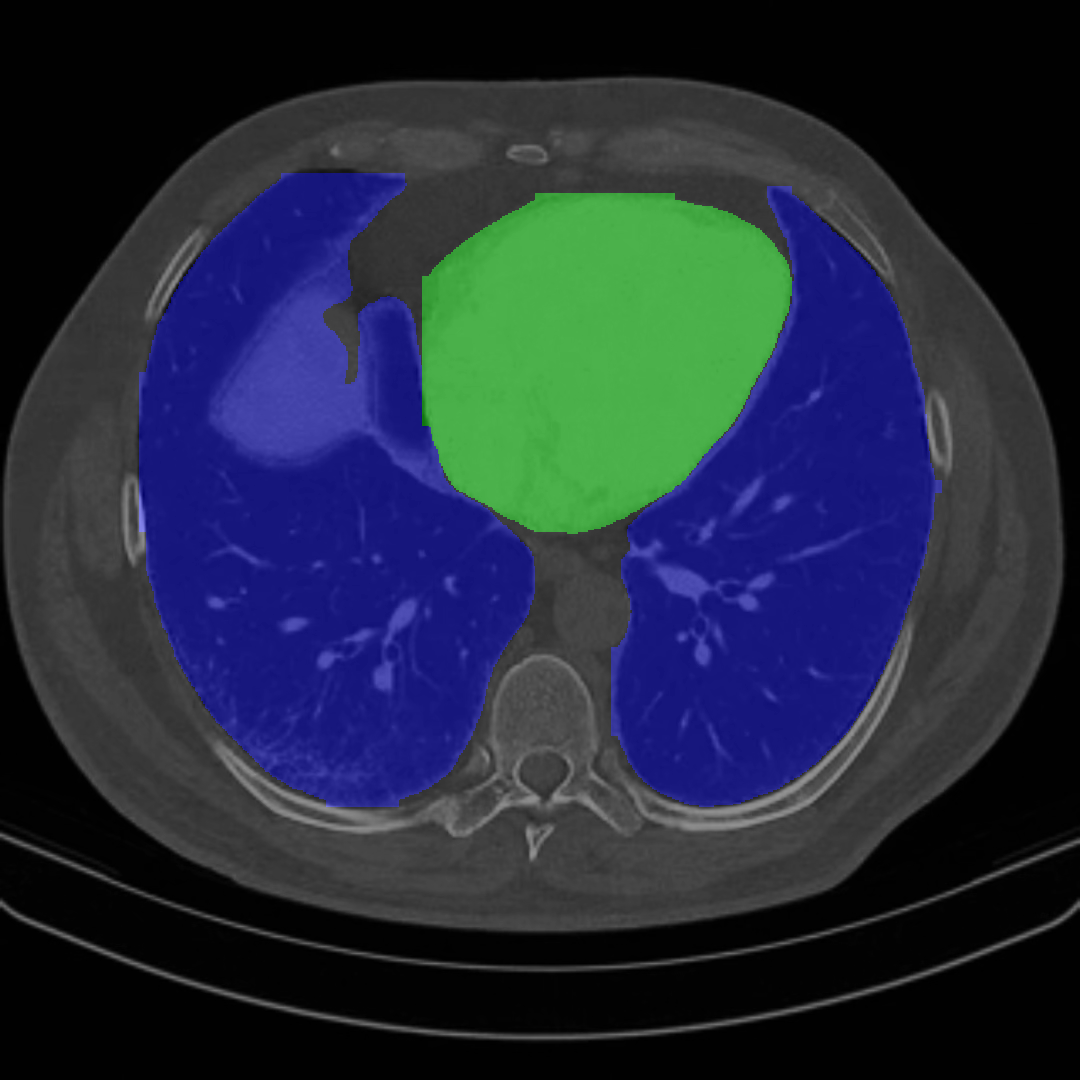

처리 완료 (중간 프레임 유지)


In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
from IPython.display import clear_output

# ============================================
# 1. 모델 로드
# ============================================
model_path = "/content/runs/segment/chest_seg_finetune_balanced_heartboost/weights/best.pt"
model = YOLO(model_path)

# ============================================
# 2. 비디오 입력
# ============================================
video_path = "/content/흉부 CT 영상.mp4"
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise ValueError(f"비디오를 열 수 없습니다: {video_path}")

max_frames = 300
frame_interval = 2
frame_count = 0

final_frame = None

# ============================================
# 3. 프레임 처리
# ============================================
while True:
    ret, frame_bgr = cap.read()
    if not ret:
        print("영상 끝")
        break

    frame_count += 1
    if frame_count > max_frames:
        break

    if frame_count % frame_interval != 0:
        continue

    H, W = frame_bgr.shape[:2]
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

    result = model(frame_rgb, conf=0.25, iou=0.7)[0]

    if result.masks is not None and result.boxes is not None:
        mask_stack = result.masks.data.cpu().numpy()
        cls_ids = result.boxes.cls.cpu().numpy().astype(int)

        Hm, Wm = mask_stack.shape[1:]
        lungs = np.zeros((Hm, Wm), np.uint8)
        heart = np.zeros((Hm, Wm), np.uint8)
        trach = np.zeros((Hm, Wm), np.uint8)

        for i in range(len(mask_stack)):
            m = (mask_stack[i] > 0.5).astype(np.uint8)
            if cls_ids[i] == 0:
                lungs |= m
            elif cls_ids[i] == 1:
                heart |= m
            elif cls_ids[i] == 2:
                trach |= m

        mask_rgb_small = np.zeros((Hm, Wm, 3), np.uint8)
        mask_rgb_small[lungs == 1] = (0, 0, 255)
        mask_rgb_small[heart == 1] = (0, 255, 0)
        mask_rgb_small[trach == 1] = (255, 0, 0)

        mask_rgb = cv2.resize(mask_rgb_small, (W, H), interpolation=cv2.INTER_NEAREST)
        mask_bgr = cv2.cvtColor(mask_rgb, cv2.COLOR_RGB2BGR)

        show_frame = cv2.addWeighted(frame_bgr, 0.6, mask_bgr, 0.4, 0)
    else:
        show_frame = frame_bgr.copy()
        cv2.putText(show_frame, "No segmentation", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

    # 중간 프레임 저장
    if frame_count == max_frames // 2:
        final_frame = show_frame.copy()

    # 실시간 표시
    clear_output(wait=True)
    cv2_imshow(show_frame)
    print(f"프레임: {frame_count}")

cap.release()

# ============================================
# 4. 마지막에 남길 출력
# ============================================
clear_output(wait=True)
if final_frame is not None:
    cv2_imshow(final_frame)
    print("처리 완료 (중간 프레임 유지)")
else:
    print("저장된 프레임 없음")